# Clip loading

Downloads clip from s3 -> rotates -> temporal sampling -> downloads processor (from hf hub) -> Processor crops to 1:1, downscales, returns tensors

In [15]:
import matplotlib.pyplot as plt
from aitraf.paths import MANIFESTS_DIR
from aitraf.data.clip_loader import build_clip_dataset, ClipSampling
import math

In [16]:

dataset = build_clip_dataset(
    MANIFESTS_DIR / 'train.jsonl',
    MANIFESTS_DIR / 'labels.json',
    sampling=ClipSampling(num_frames=9, frame_size=224, rotation_quadrants=3),
)
sample = dataset[0]
pixel_values = sample['pixel_values']
print('tensor shape:', pixel_values.shape)
print('label:', sample['label_name'], 'id:', sample['labels'].item())
print('video:', sample['video_path'])


tensor shape: torch.Size([9, 3, 224, 224])
label: bs-royale id: 1
video: s3://aitraf/clips/25-11-07 15-47-00 5699-00.10.42.867-00.10.50.290-seg17.mp4


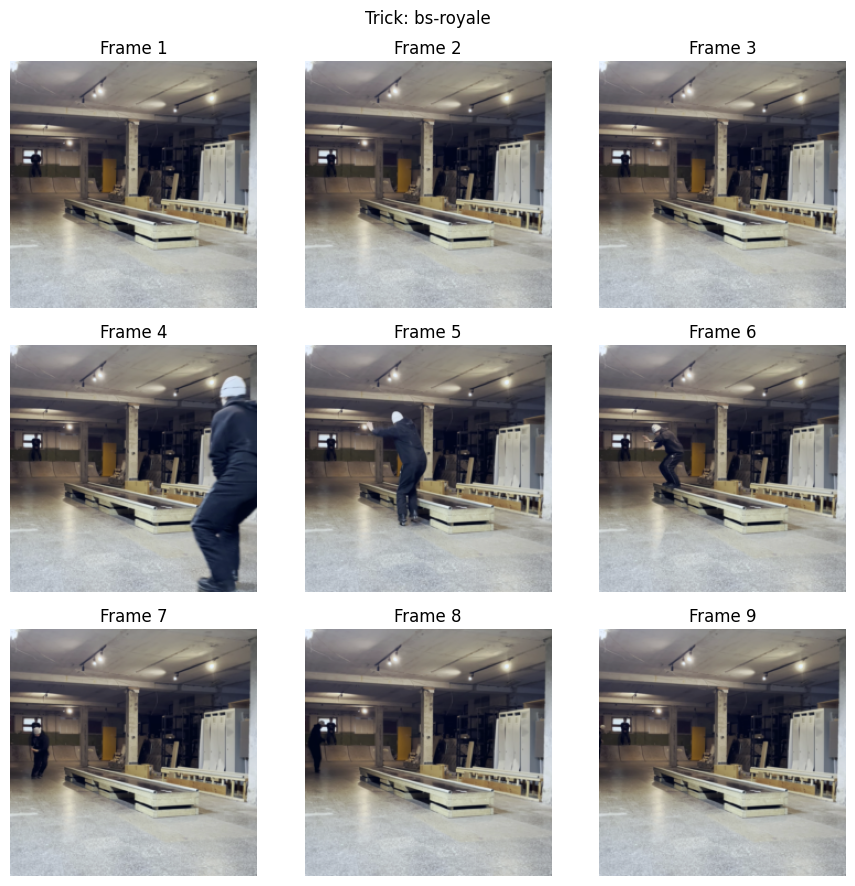

In [17]:

num_frames = pixel_values.shape[0]
cols = math.ceil(math.sqrt(num_frames))
rows = math.ceil(num_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for idx, ax in enumerate(axes):
    if idx >= num_frames:
        ax.axis('off')
        continue
    frame = pixel_values[idx].permute(1, 2, 0).cpu().numpy()
    frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-6)
    ax.imshow(frame)
    ax.set_title(f'Frame {idx+1}')
    ax.axis('off')
fig.suptitle(f"Trick: {sample['label_name']}")
plt.tight_layout()
plt.show()
